<a href="https://colab.research.google.com/github/devmlala/Climate-Data-Science-/blob/main/dados_inmet_2025_dadosV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Cleaning and Preprocessing
This section handles the initial cleaning and preprocessing of the raw data. It converts Excel-specific date formats into standard datetime objects, extracts hourly information, and combines date and hour into a unified `Timestamp` column. It also renames and drops unnecessary columns to prepare the DataFrame for further analysis.

In [12]:
import pandas as pd

# Convert 'Data' column from Excel serial date to datetime
# Excel's default epoch is December 30, 1899.
if 'Data' in df.columns:
    df['Data_Corrigida'] = pd.to_datetime(df['Data'], unit='D', origin=pd.Timestamp('1899-12-30'))

# Convert 'DATA_DE_FUNDACAO' column from Excel serial date to datetime
if 'DATA_DE_FUNDACAO' in df.columns:
    df['DATA_DE_FUNDACAO_Corrigida'] = pd.to_datetime(df['DATA_DE_FUNDACAO'], unit='D', origin=pd.Timestamp('1899-12-30'))

# Extract hour from 'Hora UTC' column (e.g., '0000 UTC' -> 0)
if 'Hora UTC' in df.columns:
    df['Hora_Corrigida'] = df['Hora UTC'].str.extract(r'(\\d{2})00 UTC').astype(int)

# Combine corrected date and hour into a single datetime column
# This operation requires 'Data_Corrigida' and 'Hora_Corrigida' to exist
if 'Data_Corrigida' in df.columns and 'Hora_Corrigida' in df.columns:
    df['Timestamp'] = df.apply(lambda row: row['Data_Corrigida'].replace(hour=row['Hora_Corrigida']), axis=1)

# Define columns to potentially drop, checking for existence first
columns_to_drop_if_exist = ['Data', 'Hora UTC', 'DATA_DE_FUNDACAO', 'Data_Corrigida', 'Hora_Corrigida']
existing_columns_to_drop = [col for col in columns_to_drop_if_exist if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)

# Rename the corrected DATA_DE_FUNDACAO column
if 'DATA_DE_FUNDACAO_Corrigida' in df.columns:
    df = df.rename(columns={'DATA_DE_FUNDACAO_Corrigida': 'DATA_DE_FUNDACAO'})

print("DataFrame with corrected 'Timestamp' and 'DATA_DE_FUNDACAO' columns:")
display(df[['Timestamp', 'DATA_DE_FUNDACAO']].head())

DataFrame with corrected 'Timestamp' and 'DATA_DE_FUNDACAO' columns:


,Timestamp,DATA_DE_FUNDACAO
0,2025-01-01 00:00:00,2000-05-07
1,2025-01-01 01:00:00,2000-05-07
2,2025-01-01 02:00:00,2000-05-07
3,2025-01-01 03:00:00,2000-05-07
4,2025-01-01 04:00:00,2000-05-07


### Data Display Formatting
This section focuses on formatting the DataFrame for display purposes. It creates a `Hora_UTC_Display` column to mimic the original 'Hora UTC' format and reorders the columns to place `Timestamp` and `Hora UTC` at the beginning, improving readability. The `Timestamp` column is also formatted to a more readable string representation for display.

In [23]:
import pandas as pd
import os

pd.set_option('display.max_columns', None) # Display all columns
pd.set_option('display.width', 1000) # Adjust display width to prevent line wrapping

# Create a column that mimics the original 'Hora UTC' format from the 'Timestamp' column
# This column will be used for display as 'Hora UTC'
if 'Timestamp' in df.columns:
    df['Hora_UTC_Display'] = df['Timestamp'].dt.strftime('%H%M UTC')

# Prepare the list of columns for reordering in df_display
current_columns = df.columns.tolist()

# Remove 'Timestamp' and 'Hora_UTC_Display' if they exist, to place them at the beginning
columns_to_move = []
if 'Timestamp' in current_columns:
    current_columns.remove('Timestamp')
    columns_to_move.append('Timestamp')
if 'Hora_UTC_Display' in current_columns:
    current_columns.remove('Hora_UTC_Display')
    columns_to_move.append('Hora_UTC_Display')

# Construct the new column order: Timestamp, then Hora_UTC_Display, then the rest
new_column_order = columns_to_move + current_columns

# Create the display DataFrame with the new order
df_display = df[new_column_order].copy() # Use .copy() to avoid SettingWithCopyWarning

# Rename 'Hora_UTC_Display' to 'Hora UTC' for display
if 'Hora_UTC_Display' in df_display.columns:
    df_display = df_display.rename(columns={'Hora_UTC_Display': 'Hora UTC'})

# Format the 'Timestamp' column for better readability in the display DataFrame
if 'Timestamp' in df_display.columns:
    df_display['Timestamp'] = df_display['Timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

print(f"\nPrimeiros 50 registros de '{os.path.basename(file_path)}' com todas as colunas (Timestamp e Hora UTC no início):")
print(df_display.tail(50))


Primeiros 50 registros de 'dados_consolidados_com_estacoes_V2.xlsx' com todas as colunas (Timestamp e Hora UTC no início):
                   Timestamp  Hora UTC  PRECIPITACAO_TOTAL_HORARIA_mm  PRESSAO_ATM  PRESSAO_ATM_MAX_HORA_ ANT  PRESSAO_ ATM_MIN_HORA_ANT  RADIACAO_GLOBAL  TEMP_AR_BULBO_SECO_HORA  TEMP_PONTO_ORVALHO  TEMP_MAX_HORA_ANT  TEMP_MIN_HORA_ANT  TEMP_ORVALHO_MAX_HORA_ANT  TEMP_ORVALHO_MIN_HORA_ANT  UMID_REL_MAX_HORA_ANT  UMID_REL_MIN_NA_HORA_ANT  UMID_REL_AR_HORARIA_porc  VENTO_DIR_HOR_gr  VENTO_RAJ_MAX_metros_por_seg  VENTO_VEL_HORARIA_metros_por_seg REGIAO  UF  ESTACAO CODIGO_wmo   LATITUDE  LONGITUDE  ALTITUDE DATA_DE_FUNDACAO
1048525  2025-03-01 13:00:00  1300 UTC                            NaN          NaN                        NaN                        NaN              NaN                      NaN                 NaN                NaN                NaN                        NaN                        NaN                    NaN                       NaN         

### Data Filtering and Export
This section filters the main DataFrame to include only records from the 'NE' region. The filtered data (`df_ne`) is then saved to a new Excel file. It also displays the total record counts before and after filtering to provide an overview of the data reduction.

In [22]:
import pandas as pd

# Filtering the DataFrame for REGIAO 'NE'
df_ne = df[df['REGIAO'] == 'NE'].copy()

# Define the output file path for the filtered data
output_file_path = '/content/dados_consolidados_REGIAO_NE.xlsx'

# Save the filtered DataFrame to a new Excel file
df_ne.to_excel(output_file_path, index=False)

print(f"Filtered data saved to '{output_file_path}'")

# Display total record counts
print(f"Total records in original DataFrame: {len(df)}")
print(f"Total records in filtered DataFrame (REGIAO == 'NE'): {len(df_ne)}")

# Display the head of the filtered DataFrame, preserving its natural column order
print("\nFirst 5 rows of the filtered DataFrame (REGIAO == 'NE'):")
display(df_ne.head())

Filtered data saved to '/content/dados_consolidados_REGIAO_NE.xlsx'
Total records in original DataFrame: 1048575
Total records in filtered DataFrame (REGIAO == 'NE'): 211719

First 5 rows of the filtered DataFrame (REGIAO == 'NE'):


,PRECIPITACAO_TOTAL_HORARIA_mm,PRESSAO_ATM,PRESSAO_ATM_MAX_HORA_ ANT,PRESSAO_ ATM_MIN_HORA_ANT,RADIACAO_GLOBAL,TEMP_AR_BULBO_SECO_HORA,TEMP_PONTO_ORVALHO,TEMP_MAX_HORA_ANT,TEMP_MIN_HORA_ANT,TEMP_ORVALHO_MAX_HORA_ANT,TEMP_ORVALHO_MIN_HORA_ANT,UMID_REL_MAX_HORA_ANT,UMID_REL_MIN_NA_HORA_ANT,UMID_REL_AR_HORARIA_porc,VENTO_DIR_HOR_gr,VENTO_RAJ_MAX_metros_por_seg,VENTO_VEL_HORARIA_metros_por_seg,REGIAO,UF,ESTACAO,CODIGO_wmo,LATITUDE,LONGITUDE,ALTITUDE,Timestamp,DATA_DE_FUNDACAO,Hora_UTC_Display
836856,0.0,1004.7,1004.7,1004.2,NaN,26.1,22.7,26.6,26.1,23.0,22.5,82.0,80.0,82.0,81.0,5.6,2.2,NE,AL,MACEIO,A303,-9.551111,-35.770278,84.12,2025-01-01 00:00:00,2003-02-25,0000 UTC
836857,0.0,1004.9,1004.9,1004.7,NaN,26.1,22.9,26.2,26.0,23.1,22.8,84.0,82.0,83.0,76.0,4.7,3.0,NE,AL,MACEIO,A303,-9.551111,-35.770278,84.12,2025-01-01 01:00:00,2003-02-25,0100 UTC
836858,0.0,1004.5,1004.9,1004.5,NaN,25.7,23.0,26.2,25.7,23.3,22.9,85.0,83.0,85.0,60.0,5.0,2.4,NE,AL,MACEIO,A303,-9.551111,-35.770278,84.12,2025-01-01 02:00:00,2003-02-25,0200 UTC
836859,0.0,1004.0,1004.5,1004.0,NaN,24.9,22.8,25.7,24.9,23.0,22.7,88.0,85.0,88.0,13.0,3.7,1.5,NE,AL,MACEIO,A303,-9.551111,-35.770278,84.12,2025-01-01 03:00:00,2003-02-25,0300 UTC
836860,0.0,1003.4,1004.0,1003.4,NaN,24.4,22.7,24.9,24.3,22.8,22.7,91.0,88.0,90.0,44.0,2.4,1.5,NE,AL,MACEIO,A303,-9.551111,-35.770278,84.12,2025-01-01 04:00:00,2003-02-25,0400 UTC


### Temperature Evolution Analysis and Visualization
This section is dedicated to analyzing and visualizing the evolution of various temperature metrics over time. It first ensures the 'Timestamp' column is in the correct datetime format and then extracts 'year' and 'hour' components. It calculates the median for multiple temperature-related columns, grouped by year and hour, and then melts the data into a long format suitable for plotting. The main intention is to compare how different temperature types (e.g., dry bulb, dew point, max/min hourly) change throughout the day and across different years in the 'NE' region using a line plot.

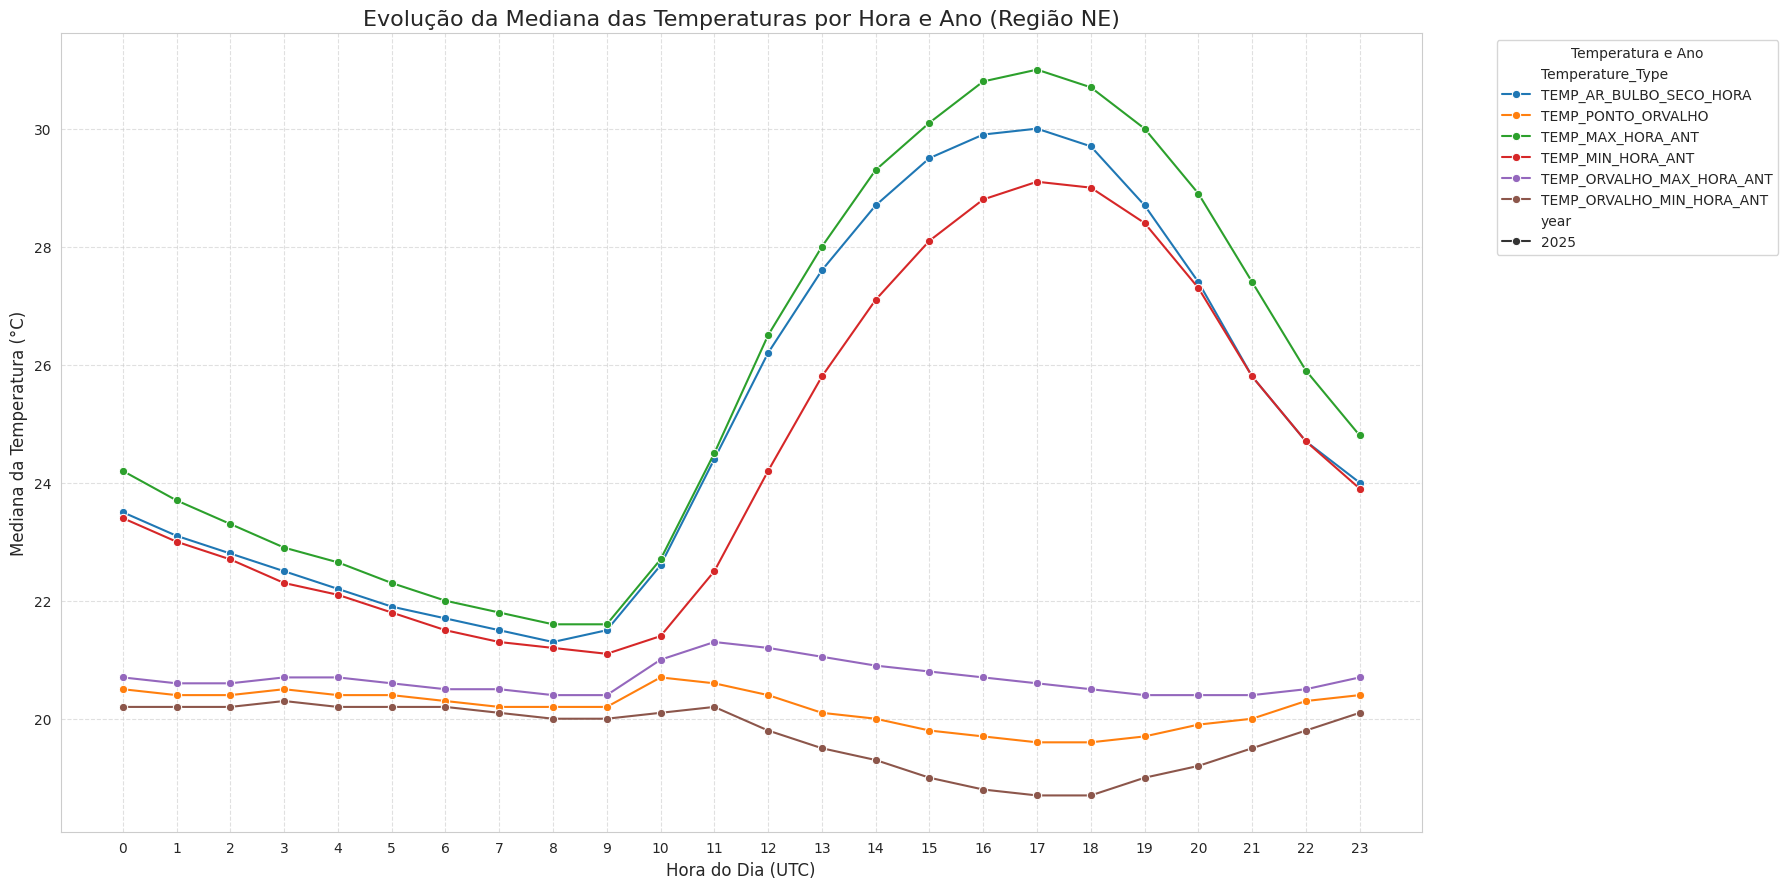

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Timestamp' is in datetime format, although it should be from previous steps.
# This step is a safeguard in case the kernel state was reset or the column type changed.
if not pd.api.types.is_datetime64_any_dtype(df_ne['Timestamp']):
    df_ne['Timestamp'] = pd.to_datetime(df_ne['Timestamp'])

# Extract 'year' and 'hour' from the 'Timestamp' column for aggregation.
df_ne['year'] = df_ne['Timestamp'].dt.year
df_ne['hour'] = df_ne['Timestamp'].dt.hour

# Define the temperature columns to compare
temp_columns = [
    'TEMP_AR_BULBO_SECO_HORA',
    'TEMP_PONTO_ORVALHO',
    'TEMP_MAX_HORA_ANT',
    'TEMP_MIN_HORA_ANT',
    'TEMP_ORVALHO_MAX_HORA_ANT',
    'TEMP_ORVALHO_MIN_HORA_ANT'
]

# Calculate the median for each specified temperature column, grouped by year and hour.
# We use .agg() to apply median to multiple columns efficiently.
hourly_median_temps_yearly = df_ne.groupby(['year', 'hour'])[temp_columns].median().reset_index()

# Melt the DataFrame to long format for easier plotting with seaborn.lineplot
melted_temps = hourly_median_temps_yearly.melt(id_vars=['year', 'hour'],
                                               value_vars=temp_columns,
                                               var_name='Temperature_Type',
                                               value_name='Median_Temperature')

# Set the aesthetic style of the plots.
sns.set_style("whitegrid")

# Create a line plot to visualize the evolution of median hourly temperature per year for different types.
plt.figure(figsize=(18, 9))
sns.lineplot(
    data=melted_temps,
    x='hour',
    y='Median_Temperature',
    hue='Temperature_Type', # Differentiate lines by temperature type
    style='year',         # Differentiate lines by year with different line styles
    palette='tab10',
    marker='o' # Add markers for each hour point
)

# Add a title and labels for better understanding of the plot.
plt.title('Evolução da Mediana das Temperaturas por Hora e Ano (Região NE)', fontsize=16)
plt.xlabel('Hora do Dia (UTC)', fontsize=12)
plt.ylabel('Mediana da Temperatura (°C)', fontsize=12)
plt.xticks(range(0, 24)) # Ensure x-axis ticks are for every hour from 0 to 23.
plt.legend(title='Temperatura e Ano', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside to avoid obscuring data.
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid for easier reading of values.
plt.tight_layout() # Adjust layout to prevent labels from being cut off.
plt.show()

### Correlação entre Radiação Global e Temperatura
Esta seção calcula a correlação de Pearson entre a `RADIACAO_GLOBAL` e a `TEMP_AR_BULBO_SECO_HORA` (temperatura do ar de bulbo seco horária) no DataFrame `df_ne`. A correlação pode indicar a força e a direção de uma relação linear entre essas duas variáveis climáticas.

In [26]:
import pandas as pd

# Calculate the correlation between 'RADIACAO_GLOBAL' and 'TEMP_AR_BULBO_SECO_HORA'
# We use the .corr() method on the DataFrame, specifying the two columns.
correlation = df_ne['RADIACAO_GLOBAL'].corr(df_ne['TEMP_AR_BULBO_SECO_HORA'])

print(f"Correlação entre Radiação Global e Temperatura do Ar (Bulbo Seco): {correlation:.3f}")

Correlação entre Radiação Global e Temperatura do Ar (Bulbo Seco): 0.609


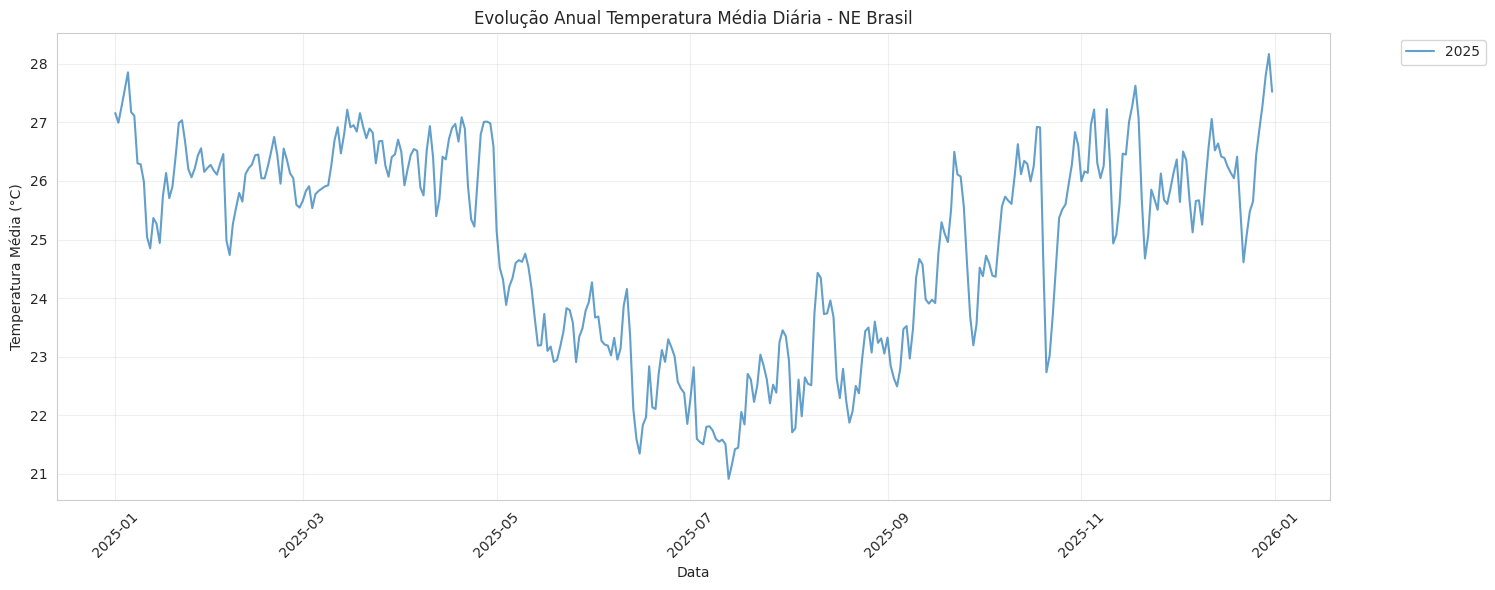

In [27]:
# Média diária por ano
df_ne['date'] = df_ne['Timestamp'].dt.date
df_ne['year'] = df_ne['Timestamp'].dt.year

serie_anual = df_ne.groupby(['year', 'date'])['TEMP_AR_BULBO_SECO_HORA'].mean().reset_index()
serie_anual['date'] = pd.to_datetime(serie_anual['date'])

plt.figure(figsize=(15, 6))
for year in sorted(serie_anual['year'].unique()):
    yearly_data = serie_anual[serie_anual['year'] == year]
    plt.plot(yearly_data['date'], yearly_data['TEMP_AR_BULBO_SECO_HORA'],
             alpha=0.7, label=f'{year}')

plt.title('Evolução Anual Temperatura Média Diária - NE Brasil')
plt.xlabel('Data')
plt.ylabel('Temperatura Média (°C)')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

📊 Análise de Temperaturas por Ano - Nordeste Brasil
Período: 2025 a 2025
Total de registros: 211,719

🔥 1. MÉDIA MENSAL por ANO e TIPO


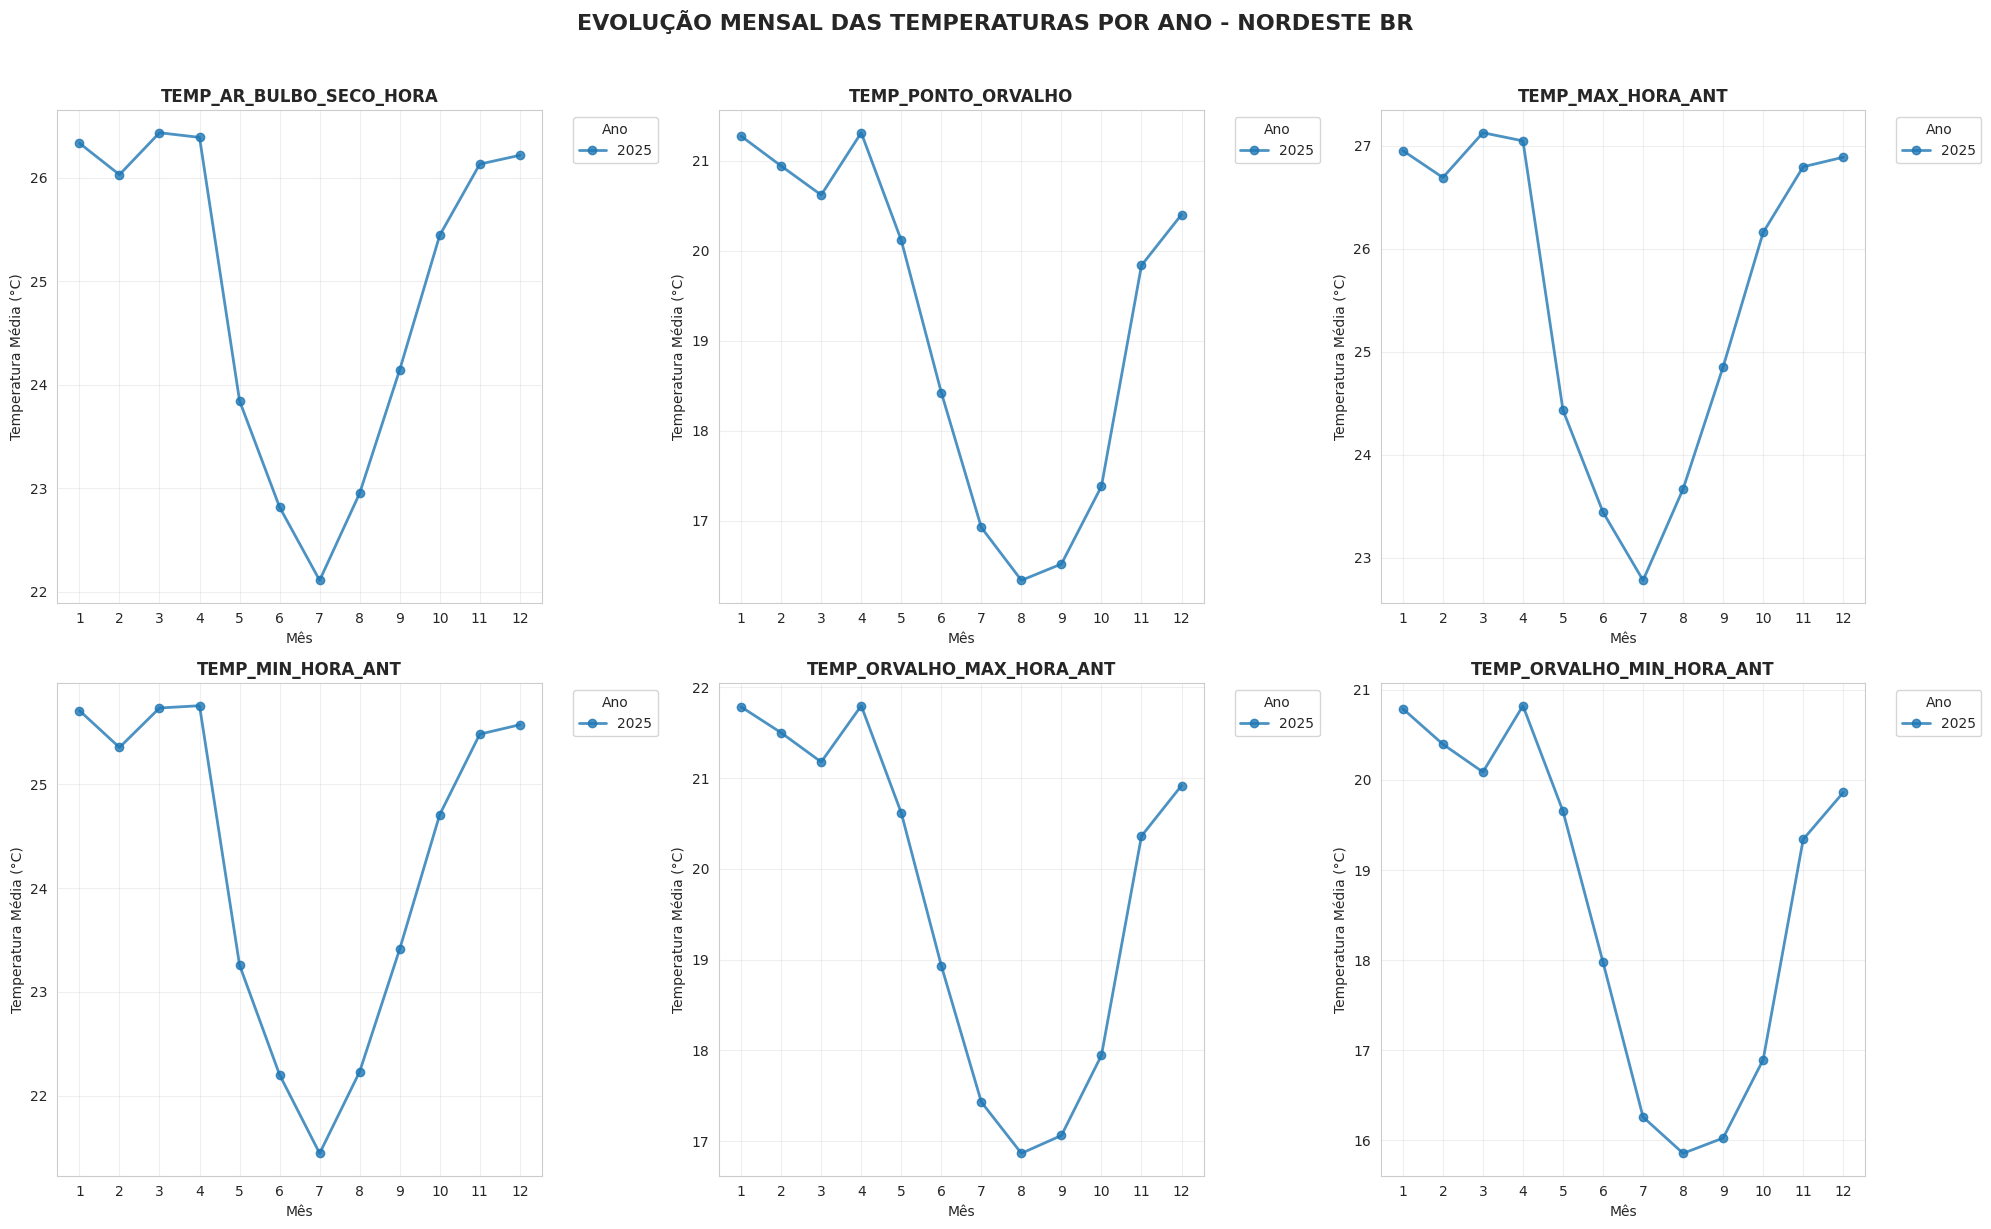


📈 2. TENDÊNCIAS ANUAIS

Médias Anuais por Tipo de Temperatura:
      TEMP_AR_BULBO_SECO_HORA  TEMP_PONTO_ORVALHO  TEMP_MAX_HORA_ANT  TEMP_MIN_HORA_ANT  TEMP_ORVALHO_MAX_HORA_ANT  TEMP_ORVALHO_MIN_HORA_ANT
year                                                                                                                                         
2025                    24.89               19.16              25.55              24.23                      19.69                      18.66


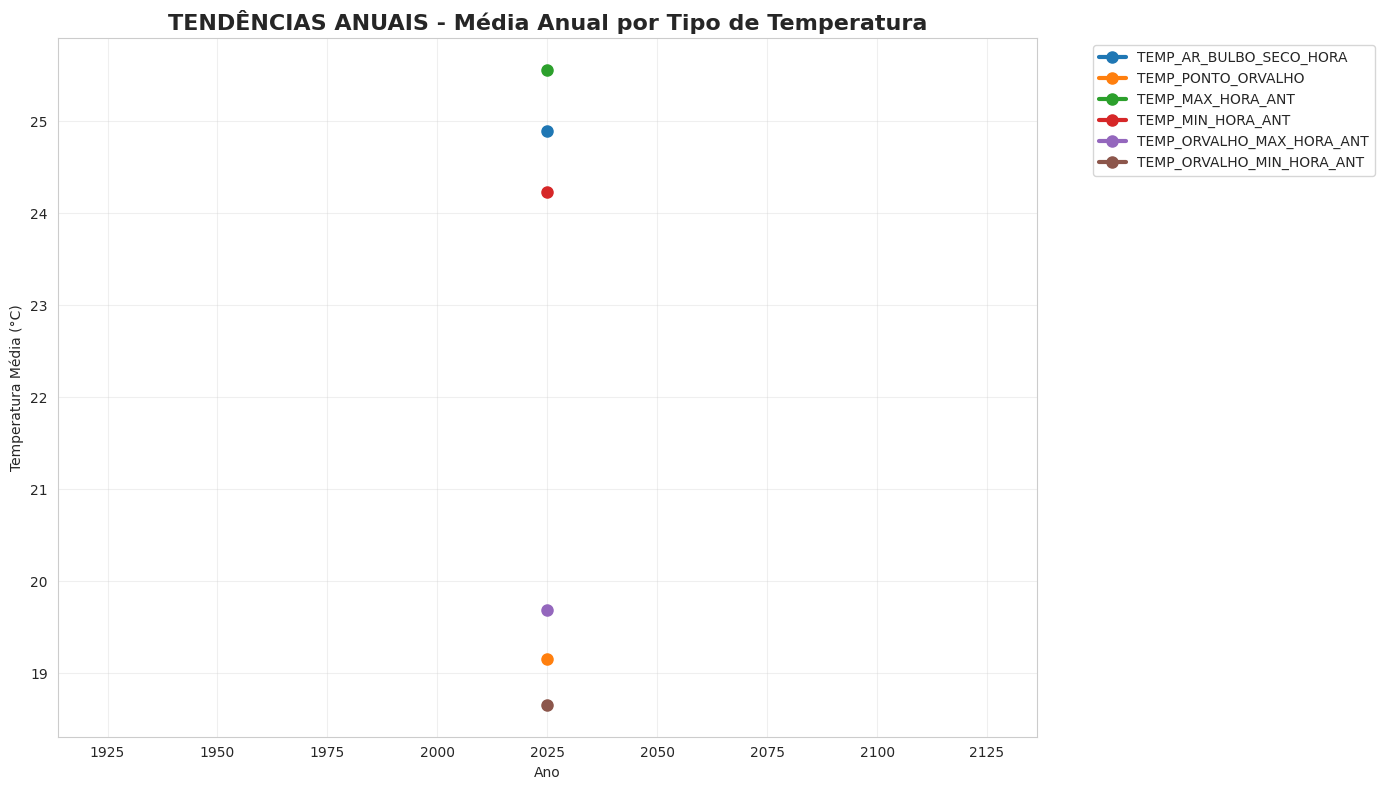


📅 3. SÉRIE TEMPORAL DIÁRIA


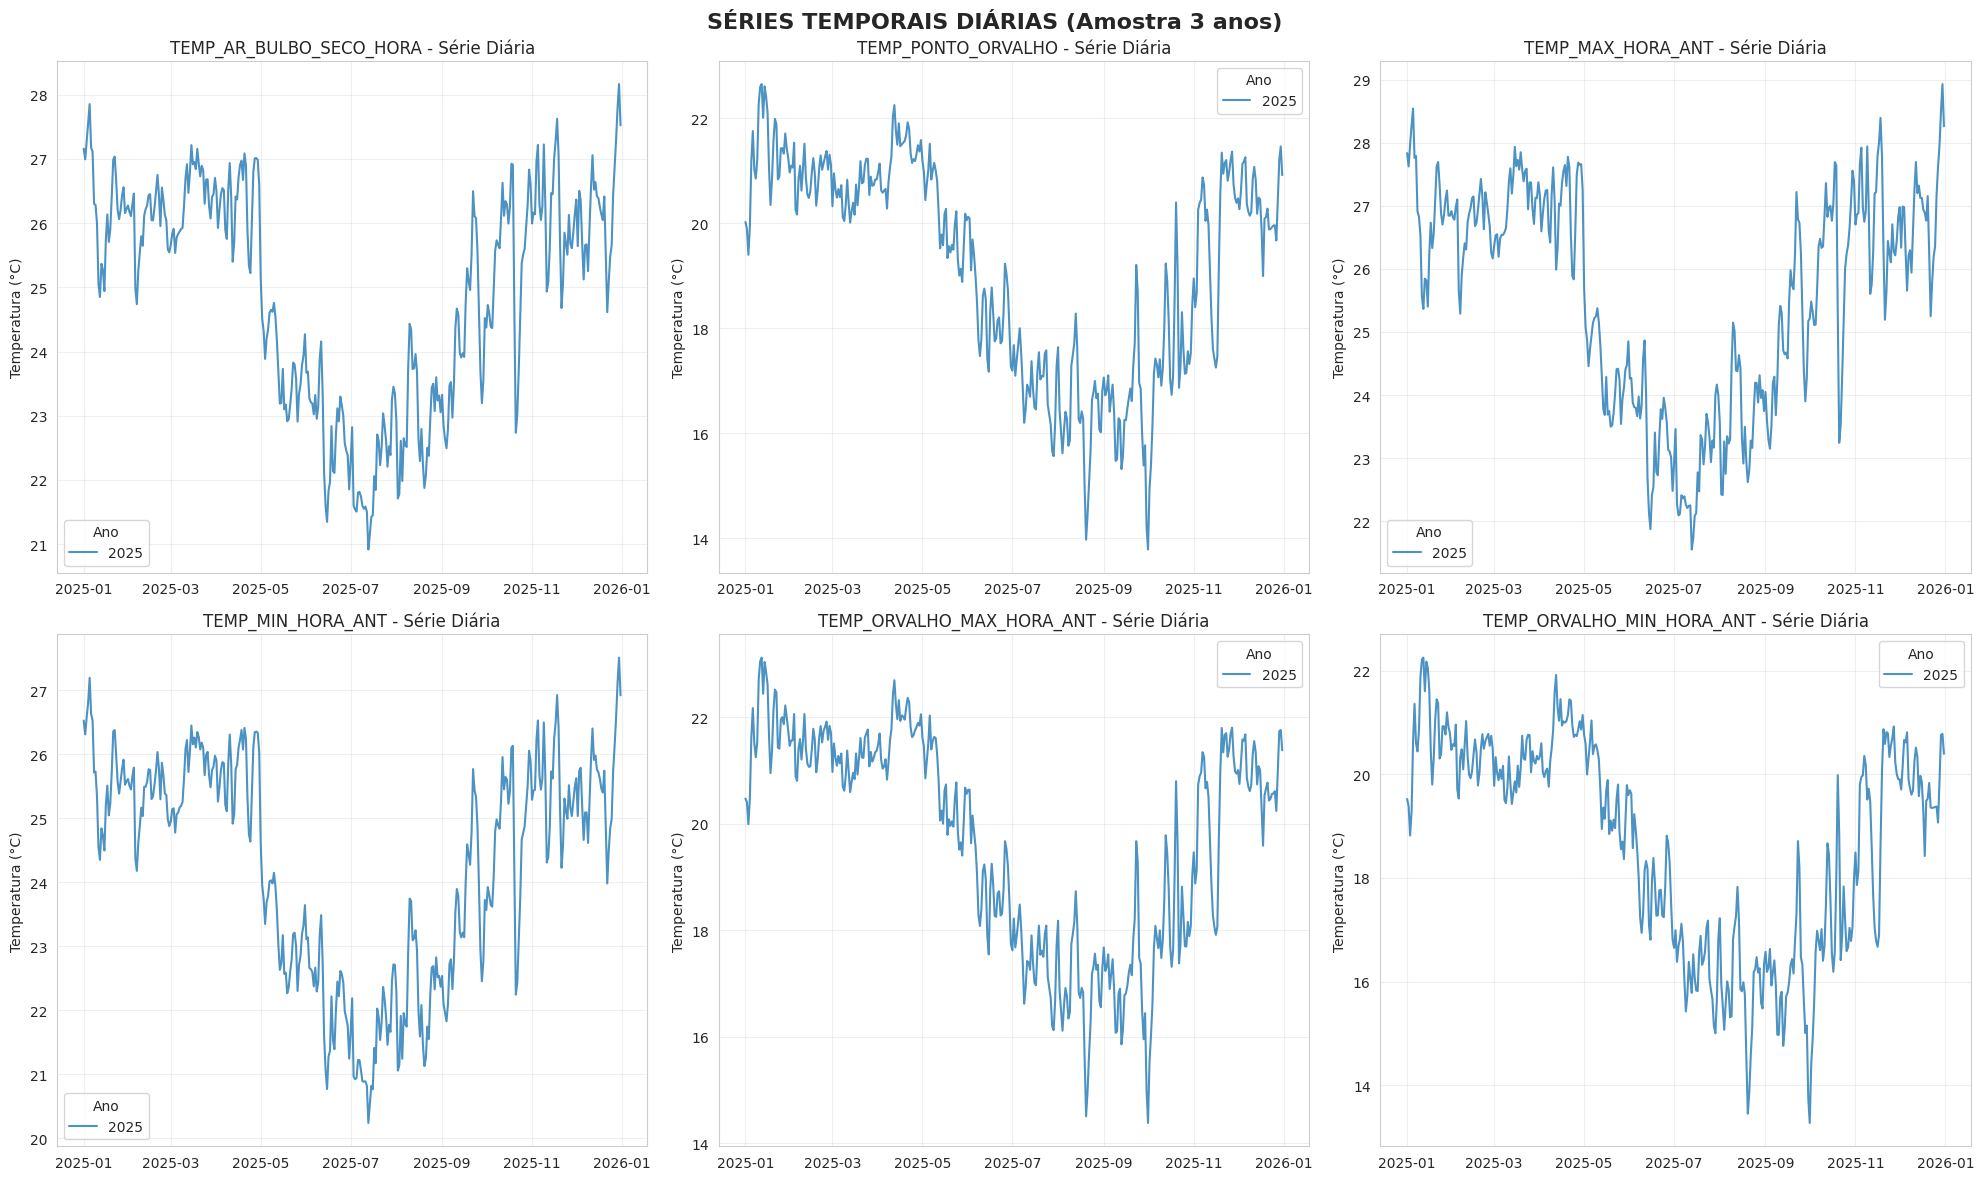


📋 4. RESUMO ESTATÍSTICO

Estatísticas por Ano (Temperatura Ar Bulbo Seco):
       mean   std  min   max
year                        
2025  24.89  4.53  9.2  40.4

🔍 5. ANOMALIAS (desvio da média histórica)


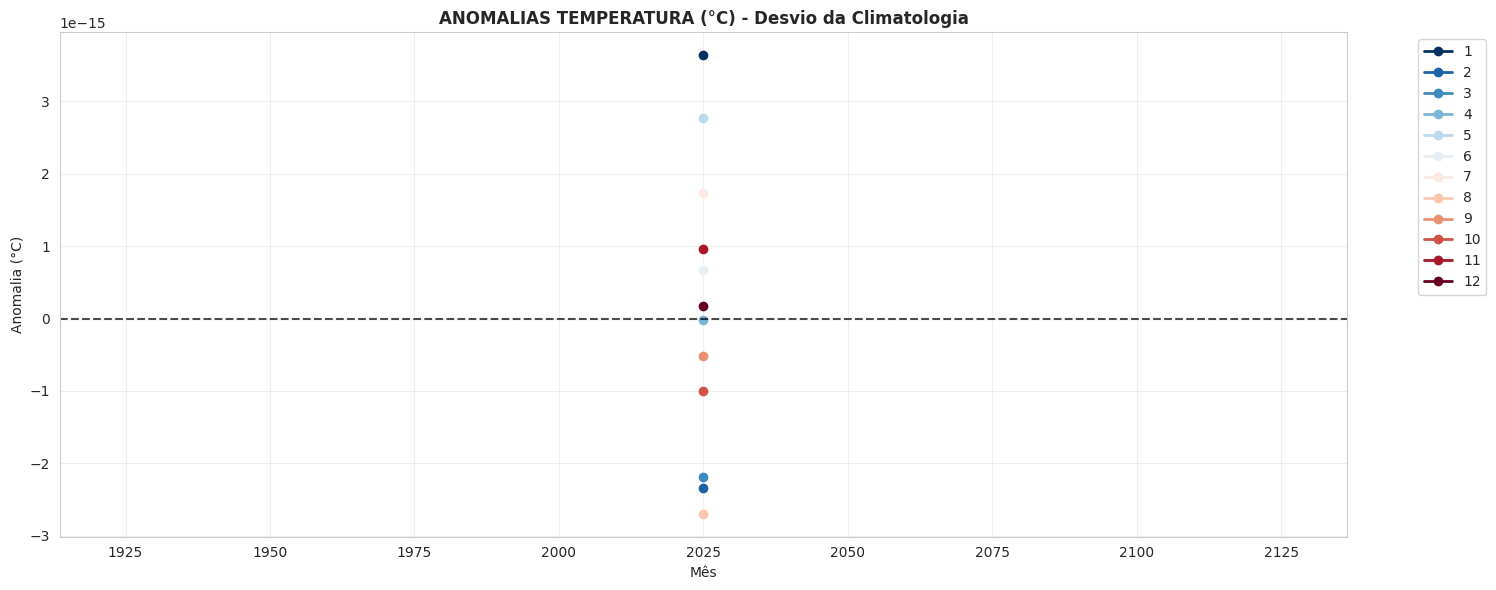


🏆 RESUMO FINAL - Mudanças Anuais:

Variação Anual (diferença do ano anterior):
      TEMP_AR_BULBO_SECO_HORA  TEMP_PONTO_ORVALHO  TEMP_MAX_HORA_ANT  TEMP_MIN_HORA_ANT  TEMP_ORVALHO_MAX_HORA_ANT  TEMP_ORVALHO_MIN_HORA_ANT
year                                                                                                                                         
2025                      NaN                 NaN                NaN                NaN                        NaN                        NaN

🌡️ AQUECIMENTO: +nan°C/ano
📉 VARIAÇÃO TOTAL: 0.00°C


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Garantir formato datetime
df_ne['Timestamp'] = pd.to_datetime(df_ne['Timestamp'])
df_ne['year'] = df_ne['Timestamp'].dt.year
df_ne['month'] = df_ne['Timestamp'].dt.month
df_ne['day'] = df_ne['Timestamp'].dt.day

# Definir todas as colunas de temperatura
temp_columns = [
    'TEMP_AR_BULBO_SECO_HORA',
    'TEMP_PONTO_ORVALHO',
    'TEMP_MAX_HORA_ANT',
    'TEMP_MIN_HORA_ANT',
    'TEMP_ORVALHO_MAX_HORA_ANT',
    'TEMP_ORVALHO_MIN_HORA_ANT'
]

print("📊 Análise de Temperaturas por Ano - Nordeste Brasil")
print(f"Período: {df_ne['year'].min()} a {df_ne['year'].max()}")
print(f"Total de registros: {len(df_ne):,}")

# ========================================
# 1. MÉDIA MENSAL POR ANO (PRINCIPAL)
# ========================================
print("\n🔥 1. MÉDIA MENSAL por ANO e TIPO")

# Agrupar por ANO + MÊS → média das 6 temperaturas
monthly_temps = df_ne.groupby(['year', 'month'])[temp_columns].mean().reset_index()

# Plot 1: Evolução anual de cada tipo
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, temp_col in enumerate(temp_columns):
    pivot_data = monthly_temps.pivot(index='month', columns='year', values=temp_col)

    pivot_data.plot(ax=axes[i], linewidth=2, marker='o', alpha=0.8)
    axes[i].set_title(f'{temp_col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Mês')
    axes[i].set_ylabel('Temperatura Média (°C)')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xticks(range(1,13))
    axes[i].legend(title='Ano', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('EVOLUÇÃO MENSAL DAS TEMPERATURAS POR ANO - NORDESTE BR',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========================================
# 2. TENDÊNCIAS ANUAIS (MÉDIA ANUAL)
# ========================================
print("\n📈 2. TENDÊNCIAS ANUAIS")

annual_means = df_ne.groupby('year')[temp_columns].mean()
print("\nMédias Anuais por Tipo de Temperatura:")
print(annual_means.round(2))

# Plot 2: Tendências anuais
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
for temp_col in temp_columns:
    ax.plot(annual_means.index, annual_means[temp_col],
            marker='o', linewidth=3, label=temp_col, markersize=8)

ax.set_title('TENDÊNCIAS ANUAIS - Média Anual por Tipo de Temperatura',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Temperatura Média (°C)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========================================
# 3. MÉDIA DIÁRIA POR ANO (SÉRIE TEMPORAL)
# ========================================
print("\n📅 3. SÉRIE TEMPORAL DIÁRIA")

# Média diária por ano
df_ne['date'] = df_ne['Timestamp'].dt.date
daily_means = df_ne.groupby(['year', 'date'])[temp_columns].mean().reset_index()
daily_means['date'] = pd.to_datetime(daily_means['date'])

# Plot 3: Séries temporais diárias (amostra dos 3 primeiros anos)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

anos_exemplo = sorted(df_ne['year'].unique())[:3]  # Primeiros 3 anos

for i, temp_col in enumerate(temp_columns):
    ax = axes[i]
    for year in anos_exemplo:
        yearly_data = daily_means[daily_means['year'] == year]
        ax.plot(yearly_data['date'], yearly_data[temp_col],
                alpha=0.8, linewidth=1.5, label=str(year))

    ax.set_title(f'{temp_col} - Série Diária')
    ax.set_ylabel('Temperatura (°C)')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Ano')

plt.suptitle('SÉRIES TEMPORAIS DIÁRIAS (Amostra 3 anos)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ========================================
# 4. RESUMO ESTATÍSTICO POR ANO
# ========================================
print("\n📋 4. RESUMO ESTATÍSTICO")

# Estatísticas descritivas por ano
print("\nEstatísticas por Ano (Temperatura Ar Bulbo Seco):")
stats_anual = df_ne.groupby('year')['TEMP_AR_BULBO_SECO_HORA'].agg(['mean', 'std', 'min', 'max']).round(2)
print(stats_anual)

# ========================================
# 5. DIFERENÇAS ENTRE ANOS (Anomalias)
# ========================================
print("\n🔍 5. ANOMALIAS (desvio da média histórica)")

# Média climatológica (todos os anos)
climatologia_mensal = df_ne.groupby('month')[temp_columns].mean()

# Anomalias por ano e mês
df_ne['clima_temp'] = df_ne.groupby('month')['TEMP_AR_BULBO_SECO_HORA'].transform('mean')
df_ne['anomalia'] = df_ne['TEMP_AR_BULBO_SECO_HORA'] - df_ne['clima_temp']

# Plot anomalias
fig, ax = plt.subplots(figsize=(15, 6))
monthly_anomalies = df_ne.groupby(['year', 'month'])['anomalia'].mean().unstack()
monthly_anomalies.plot(ax=ax, cmap='RdBu_r', linewidth=2, marker='o')
ax.set_title('ANOMALIAS TEMPERATURA (°C) - Desvio da Climatologia', fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Anomalia (°C)')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ========================================
# 6. TABELA RESUMO FINAL
# ========================================
print("\n🏆 RESUMO FINAL - Mudanças Anuais:")
mudancas = annual_means.diff().round(2)
print("\nVariação Anual (diferença do ano anterior):")
print(mudancas)

print(f"\n🌡️ AQUECIMENTO: {mudancas['TEMP_AR_BULBO_SECO_HORA'].mean():+.2f}°C/ano")
print(f"📉 VARIAÇÃO TOTAL: {annual_means['TEMP_AR_BULBO_SECO_HORA'].max() - annual_means['TEMP_AR_BULBO_SECO_HORA'].min():.2f}°C")

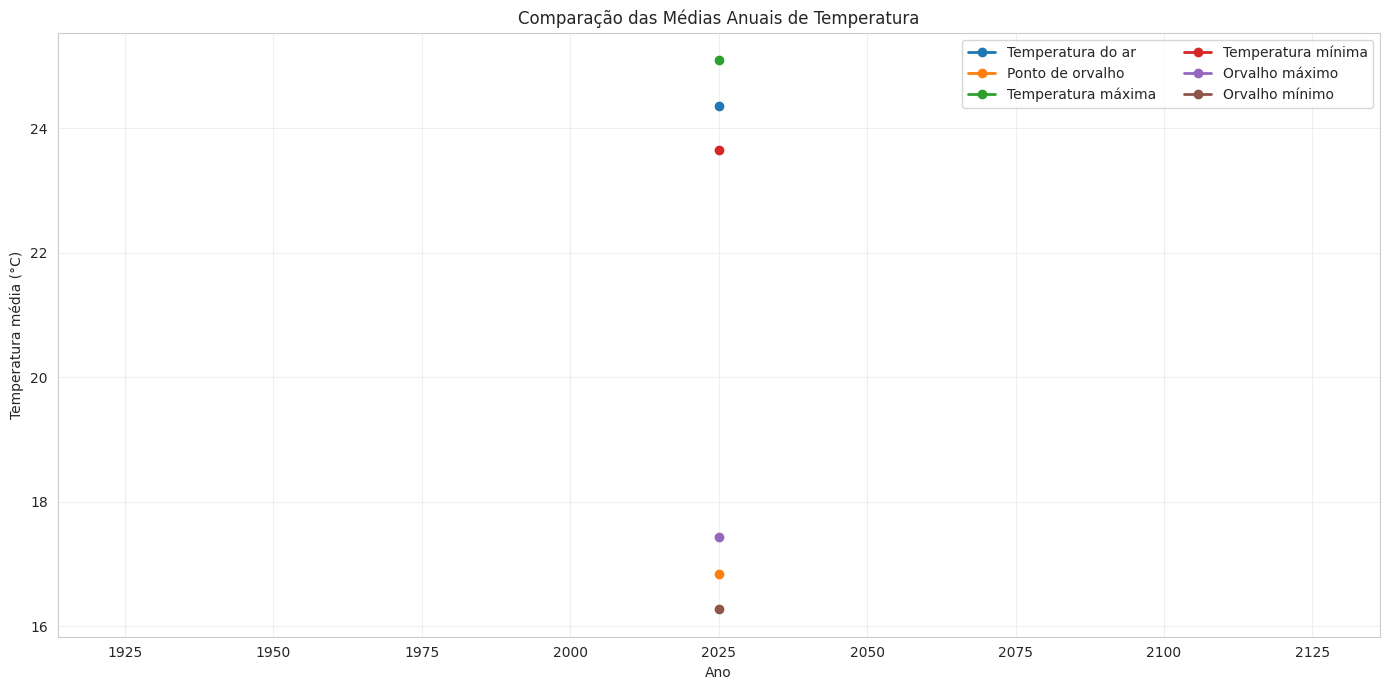

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Ajuste df para o seu dataframe já carregado
# Colunas esperadas:
# - Timestamp
# - TEMP_AR_BULBO_SECO_HORARIA (Correction applied below)
# - TEMP_PONTO_ORVALHO
# - TEMP_MAX_HORA_ANT
# - TEMP_MIN_HORA_ANT
# - TEMP_ORVALHO_MAX_HORA_ANT
# - TEMP_ORVALHO_MIN_HORA_ANT

cols = {
    'Temperatura do ar': 'TEMP_AR_BULBO_SECO_HORA', # Corrected column name
    'Ponto de orvalho': 'TEMP_PONTO_ORVALHO',
    'Temperatura máxima': 'TEMP_MAX_HORA_ANT',
    'Temperatura mínima': 'TEMP_MIN_HORA_ANT',
    'Orvalho máximo': 'TEMP_ORVALHO_MAX_HORA_ANT',
    'Orvalho mínimo': 'TEMP_ORVALHO_MIN_HORA_ANT'
}

df = df.copy()
df.columns = df.columns.str.strip()
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['Ano'] = df['Timestamp'].dt.year

for c in cols.values():
    df[c] = pd.to_numeric(df[c], errors='coerce')

annual = df.groupby('Ano')[list(cols.values())].mean().reset_index()
annual = annual.rename(columns={v: k for k, v in cols.items()})
annual = annual.sort_values('Ano')

plt.figure(figsize=(14, 7))
for col in cols.keys():
    plt.plot(annual['Ano'], annual[col], marker='o', linewidth=2, label=col)

plt.title('Comparação das Médias Anuais de Temperatura')
plt.xlabel('Ano')
plt.ylabel('Temperatura média (°C)')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

### Evolução Média Mensal das Temperaturas (Climatologia)
Esta seção visualiza a média mensal de cada tipo de temperatura, agregada ao longo de todos os anos disponíveis. Isso permite identificar padrões sazonais e a climatologia típica da região para cada mês.

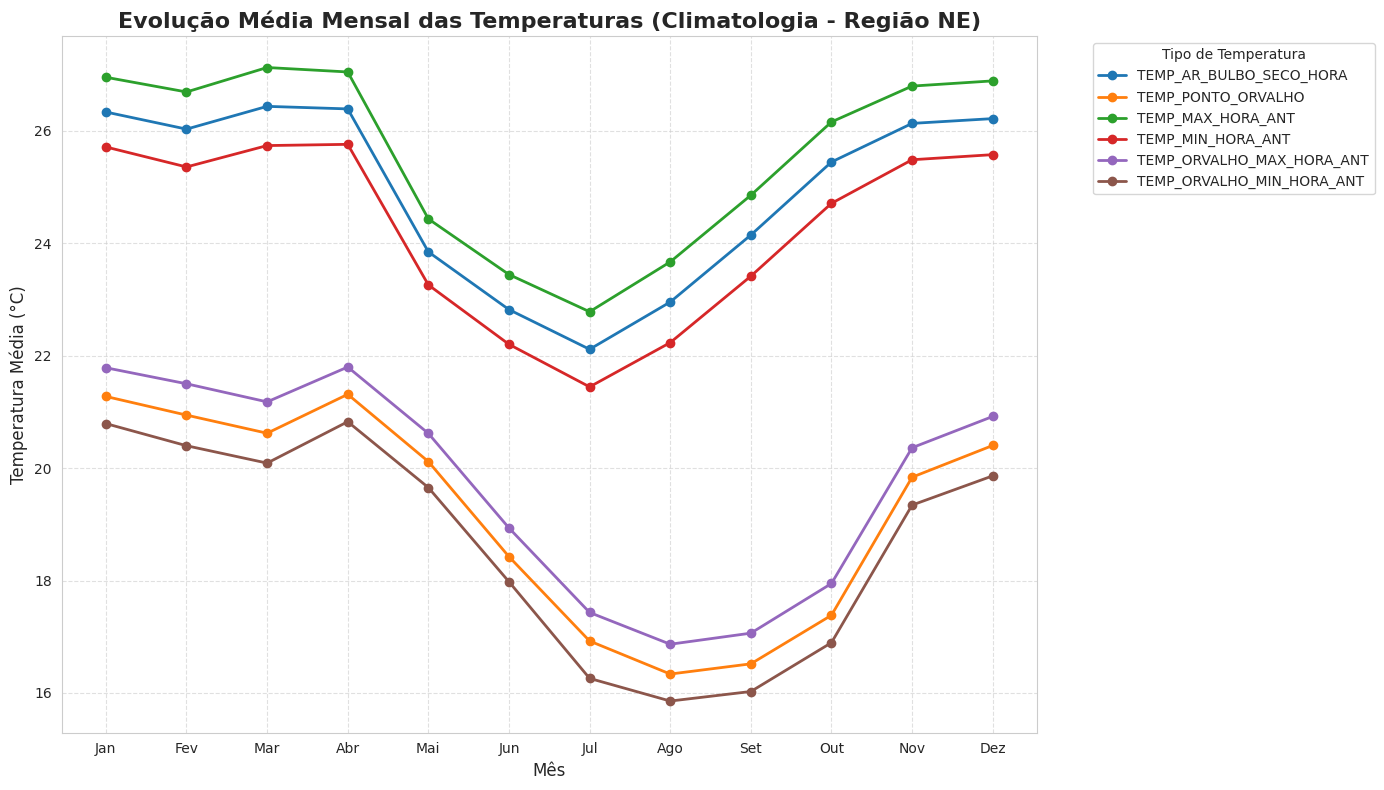

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'climatologia_mensal' DataFrame is available from previous executions.
# It contains the average for each month across all years for the temperature columns.

plt.figure(figsize=(14, 8))
for temp_col in climatologia_mensal.columns:
    plt.plot(climatologia_mensal.index, climatologia_mensal[temp_col],
             marker='o', linewidth=2, label=temp_col)

plt.title('Evolução Média Mensal das Temperaturas (Climatologia - Região NE)', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Temperatura Média (°C)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']) # Set month names as ticks
plt.legend(title='Tipo de Temperatura', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Matriz de Correlação entre Todas as Variáveis de Temperatura
Esta seção calcula e exibe a matriz de correlação de Pearson entre todas as variáveis de temperatura identificadas no DataFrame `df_ne`. Isso ajuda a entender as relações lineares entre as diferentes medições de temperatura.

Matriz de Correlação entre Variáveis de Temperatura:


,TEMP_AR_BULBO_SECO_HORA,TEMP_PONTO_ORVALHO,TEMP_MAX_HORA_ANT,TEMP_MIN_HORA_ANT,TEMP_ORVALHO_MAX_HORA_ANT,TEMP_ORVALHO_MIN_HORA_ANT
TEMP_AR_BULBO_SECO_HORA,1.000000,0.041650,0.987140,0.980249,0.107228,-0.000119
TEMP_PONTO_ORVALHO,0.041650,1.000000,0.012420,0.065727,0.987245,0.989310
TEMP_MAX_HORA_ANT,0.987140,0.012420,1.000000,0.978982,0.076832,-0.035644
TEMP_MIN_HORA_ANT,0.980249,0.065727,0.978982,1.000000,0.121229,0.029002
TEMP_ORVALHO_MAX_HORA_ANT,0.107228,0.987245,0.076832,0.121229,1.000000,0.977746
TEMP_ORVALHO_MIN_HORA_ANT,-0.000119,0.989310,-0.035644,0.029002,0.977746,1.000000


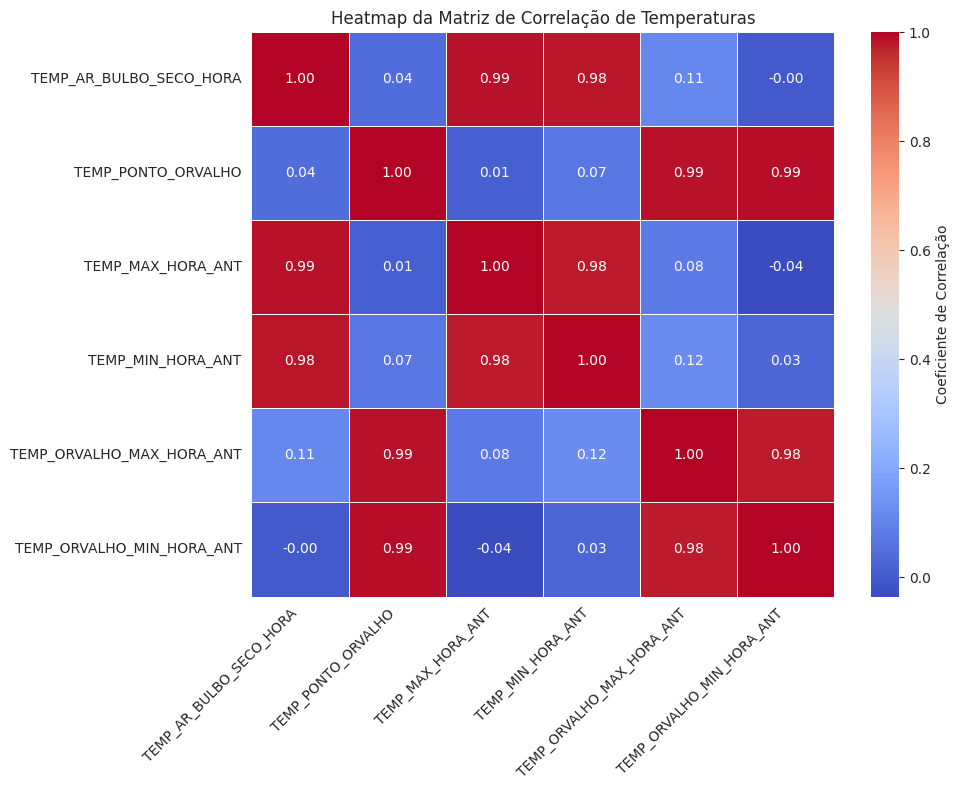

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the temperature columns based on previous analysis
temp_columns = [
    'TEMP_AR_BULBO_SECO_HORA',
    'TEMP_PONTO_ORVALHO',
    'TEMP_MAX_HORA_ANT',
    'TEMP_MIN_HORA_ANT',
    'TEMP_ORVALHO_MAX_HORA_ANT',
    'TEMP_ORVALHO_MIN_HORA_ANT'
]

# Calculate the correlation matrix for the temperature columns
correlation_matrix = df_ne[temp_columns].corr()

print("Matriz de Correlação entre Variáveis de Temperatura:")
display(correlation_matrix)

# Optionally, visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Coeficiente de Correlação'}
)
plt.title('Heatmap da Matriz de Correlação de Temperaturas')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Evolução Anual Comparativa das Temperaturas Médias
Esta seção visualiza a evolução anual das médias de cada tipo de temperatura. O gráfico de linha permite comparar as tendências históricas de diferentes medições de temperatura ao longo dos anos.

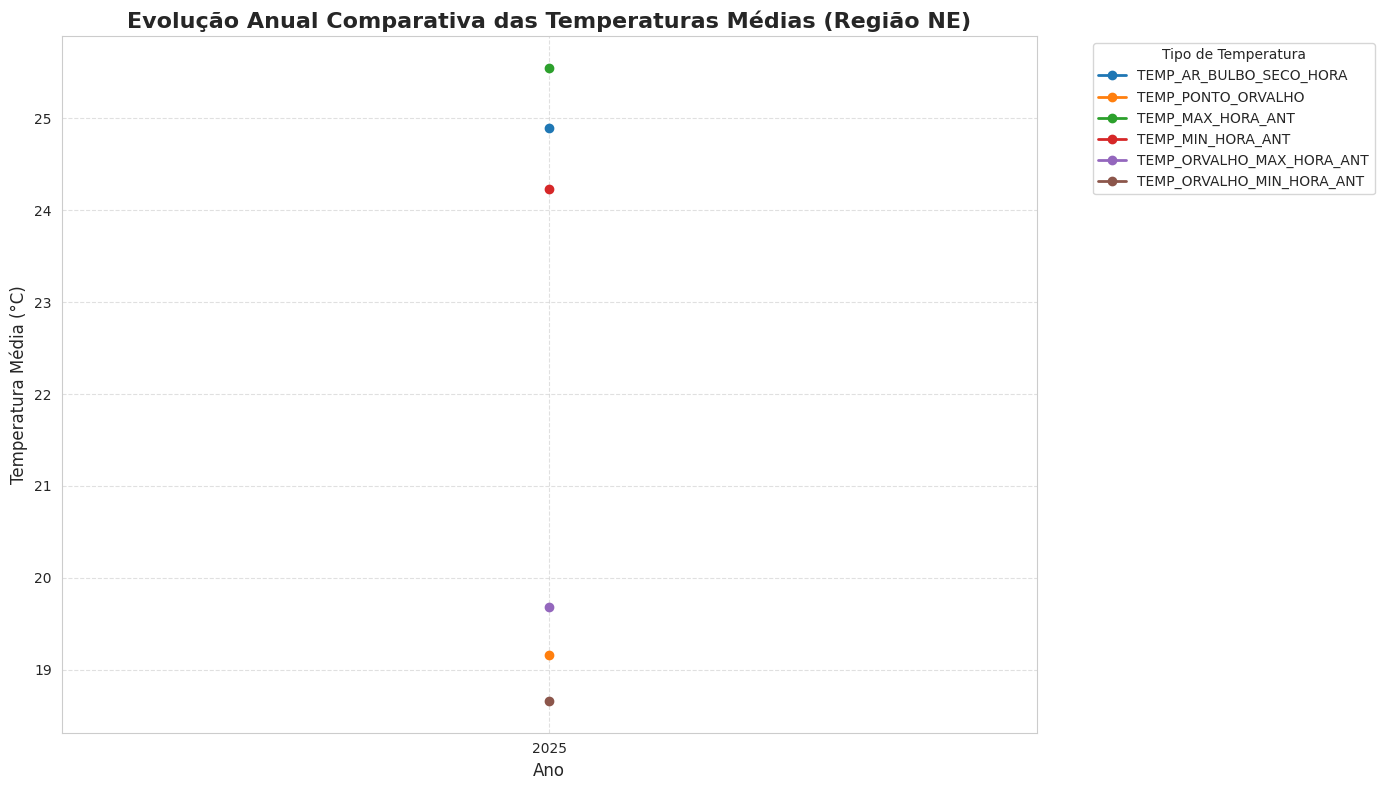

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'annual_means' DataFrame is already available from previous executions in the kernel state.
# It contains annual averages for each temperature type.

plt.figure(figsize=(14, 8))
for temp_col in annual_means.columns:
    plt.plot(annual_means.index, annual_means[temp_col],
             marker='o', linewidth=2, label=temp_col)

plt.title('Evolução Anual Comparativa das Temperaturas Médias (Região NE)', fontsize=16, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Temperatura Média (°C)', fontsize=12)
plt.legend(title='Tipo de Temperatura', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(annual_means.index) # Ensure all years are shown as ticks
plt.tight_layout()
plt.show()